# Import Libraries

Grid search fusion weight alpha untuk:

```
prob_fused = alpha * prob_text + (1 - alpha) * prob_image
```

In [27]:
import json
import pickle
import re
from pathlib import Path
from urllib.parse import unquote, urlparse
import joblib
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix


In [28]:
def clean_url(url):
    parsed = urlparse(url)
    url = parsed.netloc + parsed.path
    url = unquote(url).lower()
    url = re.sub(r"https?:\/\/", "", url)
    url = re.sub(r"[-_/]", " ", url)
    url = re.sub(r"[^a-zA-Z0-9\s]", " ", url)
    url = re.sub(r"(\d)([a-z])", r"\1 \2", url)
    url = re.sub(r"([a-z])(\d)", r"\1 \2", url)
    url = re.sub(r"\s+", " ", url).strip()
    return url

In [29]:
BASE_DIR = Path(".")
BIN_DIR = BASE_DIR / "bin"
CSV_PATH = BASE_DIR / "dataset" / "dataset_crawl_070526_with_images_path.csv"

# Load Models

In [30]:
text_model = tf.keras.models.load_model(str(BIN_DIR / 'text_classifier.keras'))
with open(BIN_DIR / 'text_tfidf_vectorizer.pkl', 'rb') as f:
    text_vectorizer = pickle.load(f)

In [31]:
image_model = tf.keras.models.load_model(str(BIN_DIR / 'image_classifier.keras'))
image_scaler = joblib.load(BIN_DIR / 'image_scaler.pkl')
print(f'Image model: {type(image_model).__name__}')

Image model: Sequential


# Load Dataset

In [32]:
df = pd.read_csv(CSV_PATH)
mask = df["Screenshot_Path"].notna() & (df["Screenshot_Path"] != "")
df_img = df[mask].copy().reset_index(drop=True)
X_img = np.load(BIN_DIR / 'image_features.npy')
img_ids = np.load(BIN_DIR / 'image_ids.npy')
id_map = {i: idx for idx, i in enumerate(img_ids)}
order = [id_map[wid] for wid in df_img["Webpage_id"]]
X_img = X_img[order]
y = (df_img["Tag"] == "gambling").astype(int).values
print(f'Samples: {len(df_img)}')
print(f'Gambling: {y.sum()} / Non-gambling: {(1 - y).sum()}')

Samples: 37811
Gambling: 12503 / Non-gambling: 25308


In [33]:
groups = df_img["Domain"].values

gkf = StratifiedGroupKFold(n_splits=5)

oof_text_probs = np.zeros(len(df_img))
oof_image_probs = np.zeros(len(df_img))

# Predictions from Both Models

In [34]:
OOF_TEXT_PATH = BIN_DIR / 'oof_text_probs.npy'
OOF_IMAGE_PATH = BIN_DIR / 'oof_image_probs.npy'

if OOF_TEXT_PATH.exists() and OOF_IMAGE_PATH.exists():
    oof_text_probs = np.load(OOF_TEXT_PATH)
    oof_image_probs = np.load(OOF_IMAGE_PATH)
    print("Loaded saved OOF probabilities from bin/.")
else:
    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(df_img, y, groups),
        1,
    ):

        print(f"\nFold {fold}/5")

        # ===================================
        # TEXT MODEL
        # ===================================

        X_text_train = (
            df_img.iloc[train_idx]["Url"]
            .apply(clean_url)
            .values
        )

        X_text_val = (
            df_img.iloc[val_idx]["Url"]
            .apply(clean_url)
            .values
        )

        X_train_tfidf = text_vectorizer.transform(X_text_train)
        X_val_tfidf = text_vectorizer.transform(X_text_val)

        fold_text_model = tf.keras.models.clone_model(
            text_model
        )

        fold_text_model.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=0.0005
            ),
            loss="binary_crossentropy",
        )

        fold_text_model.fit(
            X_train_tfidf,
            y[train_idx],
            epochs=20,
            batch_size=64,
            verbose=0,
        )

        oof_text_probs[val_idx] = (
            fold_text_model.predict(
                X_val_tfidf,
                verbose=0,
            )
            .ravel()
        )

        # ===================================
        # IMAGE MODEL (Deep Learning)
        # ===================================

        fold_image_model = tf.keras.models.clone_model(image_model)
        fold_image_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005, amsgrad=True),
            loss='binary_crossentropy',
        )

        fold_image_model.fit(
            X_img[train_idx],
            y[train_idx],
            epochs=20,
            batch_size=64,
            verbose=0,
        )

        oof_image_probs[val_idx] = (
            fold_image_model
            .predict(
                X_img[val_idx],
                verbose=0,
            )
            .ravel()
        )

    np.save(OOF_TEXT_PATH, oof_text_probs)
    np.save(OOF_IMAGE_PATH, oof_image_probs)
    print("Saved OOF probabilities to bin/.")


Loaded saved OOF probabilities from bin/.


In [35]:
prob_text = oof_text_probs
prob_image = oof_image_probs

# Text Model Evaluation

In [36]:
# Find optimal threshold for text on this subset
best_text_f1, best_text_th = 0.0, 0.5
for th in np.arange(0.3, 0.85, 0.02):
    f1 = f1_score(y, (prob_text >= th).astype(int))
    if f1 > best_text_f1:
        best_text_f1, best_text_th = f1, th
print(f'Text optimal threshold on subset: {best_text_th:.2f}')
print(f'Text F1 on subset: {best_text_f1:.4f}')

Text optimal threshold on subset: 0.40
Text F1 on subset: 0.9663


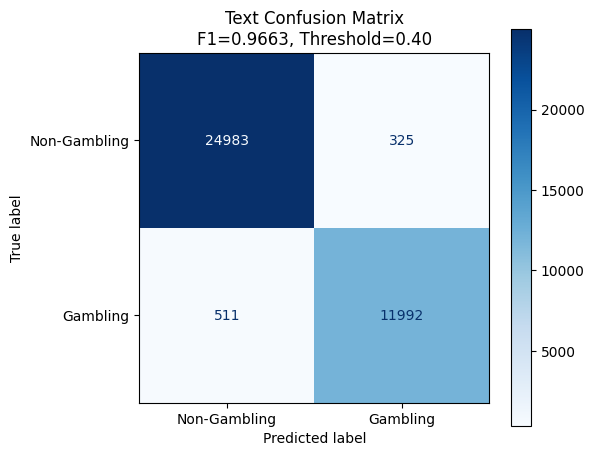

Confusion Matrix (text):
[[24983   325]
 [  511 11992]]


In [37]:
text_pred_subset = (prob_text >= best_text_th).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, text_pred_subset,
    display_labels=["Non-Gambling", "Gambling"],
    cmap="Blues", values_format="d", ax=ax,
)
ax.set_title(f"Text Confusion Matrix\nF1={best_text_f1:.4f}, Threshold={best_text_th:.2f}")
plt.tight_layout()
plt.show()
cm = confusion_matrix(y, text_pred_subset)
print("Confusion Matrix (text):")
print(cm)

In [38]:
print("\n=== Text Classification Report ===")
print(classification_report(y, text_pred_subset, target_names=["Non-Gambling", "Gambling"], digits=4))


=== Text Classification Report ===
              precision    recall  f1-score   support

Non-Gambling     0.9800    0.9872    0.9835     25308
    Gambling     0.9736    0.9591    0.9663     12503

    accuracy                         0.9779     37811
   macro avg     0.9768    0.9731    0.9749     37811
weighted avg     0.9779    0.9779    0.9778     37811



# Image Model Evaluation

In [39]:
# Find optimal threshold for image on this subset
best_image_f1, best_image_th = 0.0, 0.5
for th in np.arange(0.3, 0.85, 0.02):
    f1 = f1_score(y, (prob_image >= th).astype(int))
    if f1 > best_image_f1:
        best_image_f1, best_image_th = f1, th
print(f'Image optimal threshold on subset: {best_image_th:.2f}')
print(f'Image F1 on subset: {best_image_f1:.4f}')

Image optimal threshold on subset: 0.42
Image F1 on subset: 0.8784


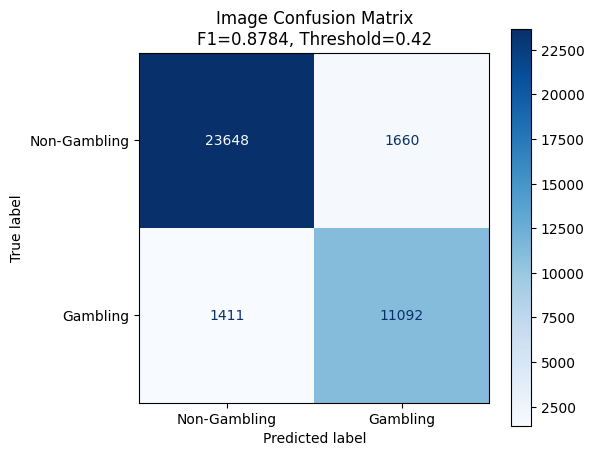

Confusion Matrix (image):
[[23648  1660]
 [ 1411 11092]]


In [40]:
image_pred_subset = (prob_image >= best_image_th).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y, image_pred_subset,
    display_labels=["Non-Gambling", "Gambling"],
    cmap="Blues", values_format="d", ax=ax,
)
ax.set_title(f"Image Confusion Matrix\nF1={best_image_f1:.4f}, Threshold={best_image_th:.2f}")
plt.tight_layout()
plt.show()
cm = confusion_matrix(y, image_pred_subset)
print("Confusion Matrix (image):")
print(cm)

In [41]:
print("\n=== Image Classification Report ===")
print(classification_report(y, image_pred_subset, target_names=["Non-Gambling", "Gambling"], digits=4))


=== Image Classification Report ===
              precision    recall  f1-score   support

Non-Gambling     0.9437    0.9344    0.9390     25308
    Gambling     0.8698    0.8871    0.8784     12503

    accuracy                         0.9188     37811
   macro avg     0.9068    0.9108    0.9087     37811
weighted avg     0.9193    0.9188    0.9190     37811



# Grid Search Fusion Weight Alpha

In [42]:
results = []
best_alpha, best_f1, best_th = 0.5, 0.0, 0.5
for alpha in np.arange(0.0, 1.05, 0.05):
    prob_fused = alpha * prob_text + (1.0 - alpha) * prob_image
    best_f1_alpha, best_th_alpha = 0.0, 0.5
    for th in np.arange(0.3, 0.85, 0.02):
        f1 = f1_score(y, (prob_fused >= th).astype(int))
        if f1 > best_f1_alpha:
            best_f1_alpha, best_th_alpha = f1, th
    results.append({'alpha': round(alpha, 2), 'threshold': round(float(best_th_alpha), 2), 'f1': round(float(best_f1_alpha), 4)})
    if best_f1_alpha > best_f1:
        best_f1, best_alpha, best_th = best_f1_alpha, alpha, best_th_alpha

In [43]:
results_df = pd.DataFrame(results)
display(results_df)
print(f'\nText-only F1 (th={best_text_th:.2f}):  {best_text_f1:.4f}')
print(f'Image-only F1 (th={best_image_th:.2f}): {best_image_f1:.4f}')
print(f'\nBest alpha: {best_alpha:.2f}')
print(f'Threshold: {best_th:.2f}')
print(f'Fusion F1: {best_f1:.4f}')

,alpha,threshold,f1
0,0.00,0.42,0.8784
1,0.05,0.46,0.8848
2,0.10,0.46,0.8919
3,0.15,0.42,0.8985
4,0.20,0.44,0.9066
5,0.25,0.40,0.9137
6,0.30,0.30,0.9275
7,0.35,0.34,0.9379
8,0.40,0.40,0.9515
9,0.45,0.44,0.9609



Text-only F1 (th=0.40):  0.9663
Image-only F1 (th=0.42): 0.8784

Best alpha: 0.50
Threshold: 0.50
Fusion F1: 0.9812


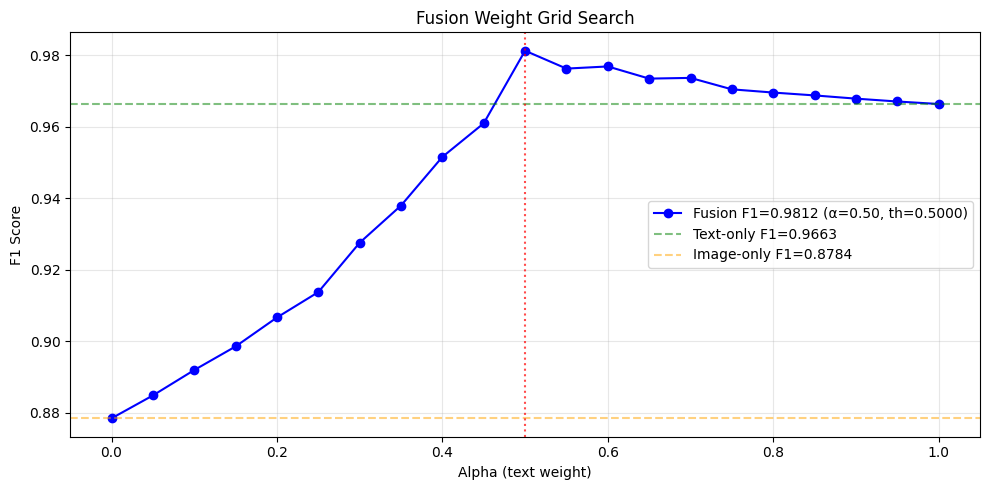


=== Ringkasan Grid Search Alpha ===
 alpha  threshold     f1
  0.00       0.42 0.8784
  0.05       0.46 0.8848
  0.10       0.46 0.8919
  0.15       0.42 0.8985
  0.20       0.44 0.9066
  0.25       0.40 0.9137
  0.30       0.30 0.9275
  0.35       0.34 0.9379
  0.40       0.40 0.9515
  0.45       0.44 0.9609
  0.50       0.50 0.9812
  0.55       0.46 0.9762
  0.60       0.40 0.9768
  0.65       0.36 0.9734
  0.70       0.30 0.9736
  0.75       0.52 0.9704
  0.80       0.50 0.9695
  0.85       0.46 0.9687
  0.90       0.46 0.9678
  0.95       0.50 0.9670
  1.00       0.40 0.9663
Text-only  F1 = 0.9663 (threshold=0.40)
Image-only F1 = 0.8784 (threshold=0.42)
Best Fusion  F1 = 0.9812 (alpha=0.50, threshold=0.50)


In [44]:
best_f1 = results_df['f1'].max()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Fusion
ax1.plot(
    results_df['alpha'],
    results_df['f1'],
    'bo-',
    label=f'Fusion F1={best_f1:.4f} (α={best_alpha:.2f}, th={best_th:.4f})'
)

# Baseline text-only
ax1.axhline(
    best_text_f1,
    color='green',
    linestyle='--',
    alpha=0.5,
    label=f'Text-only F1={best_text_f1:.4f}'
)

# Baseline image-only
ax1.axhline(
    best_image_f1,
    color='orange',
    linestyle='--',
    alpha=0.5,
    label=f'Image-only F1={best_image_f1:.4f}'
)

# Penanda alpha terbaik (tanpa label agar legend tidak terlalu ramai)
ax1.axvline(
    best_alpha,
    color='red',
    linestyle=':',
    alpha=0.7
)

ax1.set_xlabel('Alpha (text weight)')
ax1.set_ylabel('F1 Score')
ax1.set_title('Fusion Weight Grid Search')

ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\n=== Ringkasan Grid Search Alpha ===")
print(results_df.to_string(index=False))
print(f"Text-only  F1 = {best_text_f1:.4f} (threshold={best_text_th:.2f})")
print(f"Image-only F1 = {best_image_f1:.4f} (threshold={best_image_th:.2f})")
print(f"Best Fusion  F1 = {best_f1:.4f} (alpha={best_alpha:.2f}, threshold={best_th:.2f})")


# Fusion Model Evaluation

In [45]:
best_prob_fused = (
    best_alpha * prob_text
    + (1.0 - best_alpha) * prob_image
)

best_pred = (
    best_prob_fused >= best_th
).astype(int)

Confusion Matrix (fusion):
[[25247    61]
 [  403 12100]]


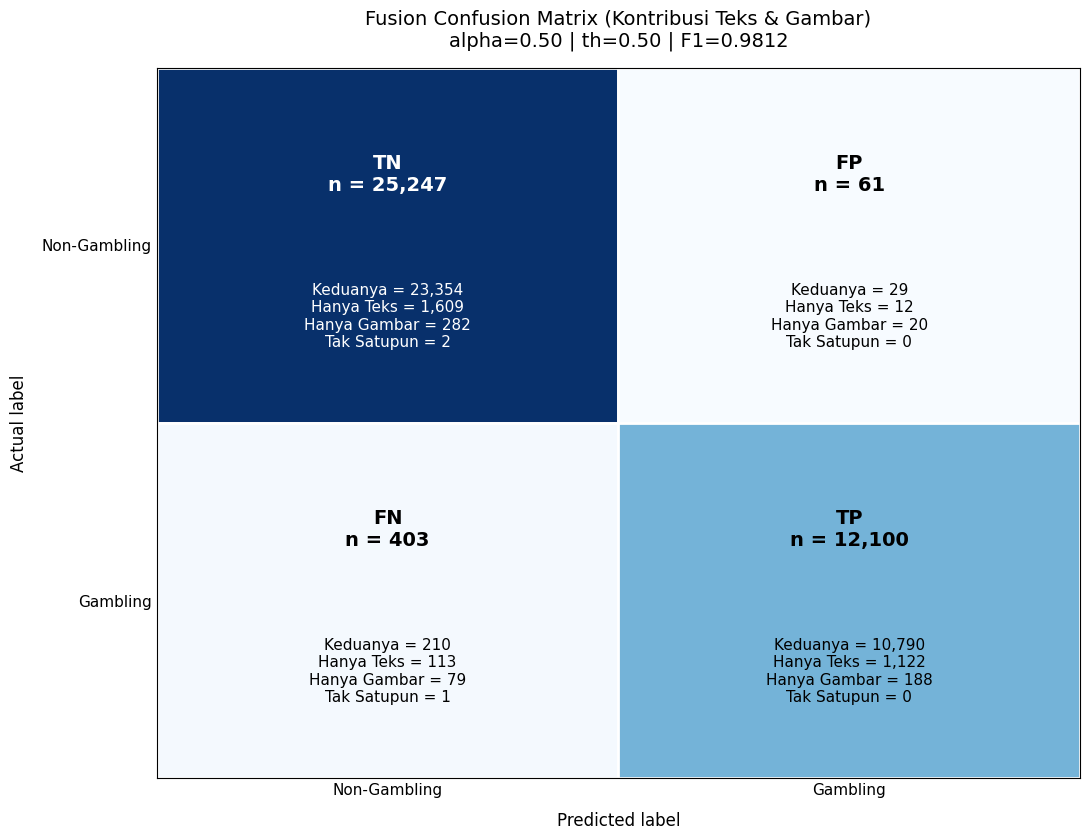


Kontribusi teks & gambar per sel confusion matrix fusion (relatif terhadap hasil fusion):
---------------------------------------------------------------------------
Sel  | Total (n) |  Keduanya | Hanya Teks | Hanya Gambar | Tak Satupun
---------------------------------------------------------------------------
TN   |    25,247 |    23,354 |      1,609 |          282 |           2
FP   |        61 |        29 |         12 |           20 |           0
FN   |       403 |       210 |        113 |           79 |           1
TP   |    12,100 |    10,790 |      1,122 |          188 |           0
---------------------------------------------------------------------------


In [51]:
text_pred_subset = (prob_text >= best_text_th).astype(int)
image_pred_subset = (prob_image >= best_image_th).astype(int)

cm = confusion_matrix(y, best_pred)
print("Confusion Matrix (fusion):")
print(cm)

cell_names = ["TN", "FP", "FN", "TP"]
cmap = plt.cm.Blues
vmax = cm.max()

def cell_counts(actual, pred):
    mask = (y == actual) & (best_pred == pred)
    keduanya = int(((text_pred_subset == pred) & (image_pred_subset == pred) & mask).sum())
    hanya_teks = int(((text_pred_subset == pred) & (image_pred_subset != pred) & mask).sum())
    hanya_gambar = int(((text_pred_subset != pred) & (image_pred_subset == pred) & mask).sum())
    tak_satu = int(((text_pred_subset != pred) & (image_pred_subset != pred) & mask).sum())
    return keduanya, hanya_teks, hanya_gambar, tak_satu

fig, ax = plt.subplots(figsize=(11, 8.5))

for actual in range(2):
    for pred in range(2):
        label = cell_names[actual * 2 + pred]
        n = cm[actual, pred]
        keduanya, hanya_teks, hanya_gambar, tak_satu = cell_counts(actual, pred)

        # Gambar kotak
        rect = plt.Rectangle(
            (pred, 1 - actual), 1, 1,
            facecolor=cmap(n / vmax), edgecolor="white", linewidth=2,
        )
        ax.add_patch(rect)

        # Tentukan warna teks agar kontras dengan background
        color = "white" if n > vmax * 0.6 else "black"
        
        # Posisi titik tengah kotak
        center_x = pred + 0.5
        center_y = 1 - actual + 0.5
        
        # 1. Teks Utama (Label & Total n)
        main_text = f"{label}\nn = {n:,}"
        ax.text(center_x, center_y + 0.20, main_text,
                ha="center", va="center", fontsize=14, fontweight="bold", color=color)
        
        # 2. Teks Rincian (Detail Kontribusi)
        # Menggunakan \n (newline) jauh lebih rapi dibanding mengatur koordinat Y satu per satu
        detail_text = (
            f"Keduanya = {keduanya:,}\n"
            f"Hanya Teks = {hanya_teks:,}\n"
            f"Hanya Gambar = {hanya_gambar:,}\n"
            f"Tak Satupun = {tak_satu:,}"
        )
        ax.text(center_x, center_y - 0.20, detail_text,
                ha="center", va="center", fontsize=11, color=color)

ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(["Non-Gambling", "Gambling"])
ax.set_yticks([1.5, 0.5])
ax.set_yticklabels(["Non-Gambling", "Gambling"])
ax.set_xlabel("Predicted label", fontsize=12, labelpad=10)
ax.set_ylabel("Actual label", fontsize=12, labelpad=10)
ax.set_title(
    f"Fusion Confusion Matrix (Kontribusi Teks & Gambar)\n"
    f"alpha={best_alpha:.2f} | th={best_th:.2f} | F1={best_f1:.4f}",
    fontsize=14, pad=15
)
ax.tick_params(length=0, labelsize=11)

plt.tight_layout()
plt.show()
fig.savefig(BIN_DIR / 'fusion_confusion_matrix.png', dpi=150, bbox_inches='tight')

# Print Terminal yang dirapihkan dengan separator "|"
print("\nKontribusi teks & gambar per sel confusion matrix fusion (relatif terhadap hasil fusion):")
print("-" * 75)
print(f"{'Sel':<4} | {'Total (n)':>9} | {'Keduanya':>9} | {'Hanya Teks':>10} | {'Hanya Gambar':>12} | {'Tak Satupun':>11}")
print("-" * 75)
for actual in range(2):
    for pred in range(2):
        label = cell_names[actual * 2 + pred]
        n = cm[actual, pred]
        keduanya, hanya_teks, hanya_gambar, tak_satu = cell_counts(actual, pred)
        print(f"{label:<4} | {n:>9,} | {keduanya:>9,} | {hanya_teks:>10,} | {hanya_gambar:>12,} | {tak_satu:>11,}")
print("-" * 75)

In [47]:
print("\n=== Fusion Classification Report ===")
print(classification_report(y, best_pred, target_names=["Non-Gambling", "Gambling",], digits=4,))


=== Fusion Classification Report ===
              precision    recall  f1-score   support

Non-Gambling     0.9843    0.9976    0.9909     25308
    Gambling     0.9950    0.9678    0.9812     12503

    accuracy                         0.9877     37811
   macro avg     0.9896    0.9827    0.9860     37811
weighted avg     0.9878    0.9877    0.9877     37811



# Save Optimal Alpha

In [48]:
output = {'alpha': float(best_alpha), 'threshold': float(best_th), 'f1': float(best_f1)}
with open(BIN_DIR / 'image_fusion_alpha.json', 'w') as f:
    json.dump(output, f)
print(f'Saved to {BIN_DIR / "image_fusion_alpha.json"}')
print(json.dumps(output, indent=2))

Saved to bin/image_fusion_alpha.json
{
  "alpha": 0.5,
  "threshold": 0.5000000000000002,
  "f1": 0.9812
}
